# Agent-Based Model: Student Housing & Loneliness

This model simulates student housing choices between studios and shared housing, and tracks how housing allocation affects loneliness, mismatch, rents, supply, and public policy costs. **To be continued**

## Research focus
- How do students choose between studios and shared housing?
- How does this choice affect loneliness?
- How do different policy scenarios influence student loneliness, as well as housing demand and supply?

### 1. Imports

In [65]:
from __future__ import annotations

from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mesa

from mesa.datacollection import DataCollector

### 2. Student income generation

In [66]:
# Source: database.eurostudent.eu
INCOME_DECILE_MAX_VALUES = [
    780, 1000, 1150, 1301.67, 1461.67,
    1618.33, 1810, 2055, 2425, 6556.67
]

INCOME_DECILE_MEAN_VALUES = [
    567.24, 893.87, 1074.81, 1228.65, 1384.45,
    1537.44, 1716.70, 1930.14, 2229.87, 2983.56
]

In [67]:
# TODO nice comment here
def generate_student_incomes(n_agents, max_values, mean_values, min_income=0, seed=None, concentration=8):
    rng = np.random.default_rng(seed)

    max_values = np.array(max_values, dtype=float)
    mean_values = np.array(mean_values, dtype=float)

    lower_bounds = np.concatenate(([min_income], max_values[:-1]))
    upper_bounds = max_values

    incomes = []

    base_count = n_agents // 10
    remainder = n_agents % 10

    for i in range(10):
        count = base_count + (1 if i < remainder else 0)

        low = lower_bounds[i]
        high = upper_bounds[i]
        mean = mean_values[i]

        relative_mean = (mean - low) / (high - low)
        relative_mean = np.clip(relative_mean, 0.01, 0.99)

        alpha = relative_mean * concentration
        beta = (1 - relative_mean) * concentration

        samples = rng.beta(alpha, beta, size=count)
        decile_incomes = low + samples * (high - low)

        incomes.extend(decile_incomes)

    incomes = np.array(incomes)
    rng.shuffle(incomes)

    return incomes

In [68]:
def bimodal_sample(rng, mean1=0.25, std1=0.1, mean2=0.75, std2=0.1):
    """Bimodal trait draw using a seeded NumPy Generator ``rng``.

    Two peaks: e.g. private vs. open people, or introvert vs. extrovert split.
    Takes the model's seeded generator so traits are reproducible from the seed.
    """
    return float(rng.normal(mean1, std1) if rng.random() < 0.5
                 else rng.normal(mean2, std2))


def beta_sample(rng, alpha=1.5, beta=4.0):
    """Right-skewed trait draw using a seeded NumPy Generator ``rng``.

    Most agents have low-to-moderate values with a tail of high ones (used for time
    pressure). Uses the passed generator so the draw is reproducible from the seed.
    """
    return float(rng.beta(alpha, beta))

### 3. Student agent

Each student has an income, privacy preference, social need, time pressure, price sensitivity, and wellbeing state.  
At every step, students may update their housing preference, choose housing, and update loneliness/stress depending on their housing situation. **To be continued**

In [69]:
# =========================================================
# STUDENT AGENT
# =========================================================

class StudentAgent(mesa.Agent):
    """
    Student agent in a non-spatial housing market.

    Key idea:
    - each student has a preferred housing type
    - each step they must choose the best feasible option available now
    - loneliness evolves from mismatch, isolation, and financial stress
    - time_pressure represents urgency to settle quickly — an agent under high time
      pressure is slightly more willing to accept a studio because they need housing
      now and can't afford to wait for a shared option to become available
    """

    def __init__(
        self,
        model: "StudentHousingModel",
        income: float,
        privacy_pref: float,
        social_need: float,
        time_pressure: float,
        loneliness_sensitivity: float,
        stress_sensitivity: float,
        price_sensitivity: float,
    ):
        super().__init__(model)

        self.income = income
        self.privacy_pref = privacy_pref
        self.social_need = social_need
        self.time_pressure = time_pressure
        self.loneliness_sensitivity = loneliness_sensitivity
        self.stress_sensitivity = stress_sensitivity

        self.price_sensitivity = price_sensitivity

        # latent_preference: genuine underlying preference, fixed for agent's lifetime.
        self.latent_preference = (
            "shared" if self.social_need - self.privacy_pref > 0.1 else "studio"
        )

        # housing_preference: revealed preference, starts equal to latent but
        # updates each step via update_preference() in response to subsidy structure.
        self.housing_preference = self.latent_preference
        self.current_housing = "none"
        self.mismatch = 0.0
        self.loneliness = 0.4

        # Outcome tracking for waiting-time and match-rate measures
        self.search_time = 0
        self.total_search_time = 0
        self.ever_housed = False

        # Diagnostics (set in choose_housing; not currently collected).
        self.last_choice_utility_studio = None
        self.last_choice_utility_shared = None

    def update_preference(self) -> None:
        """
        Updates revealed housing preference each step based on the effective
        cost gap between studio and shared housing, modulated by price_sensitivity.

        Empirical basis (LMS 2025, Kences et al.):
        A hypothetical €200/month room subsidy shifts studio preference from 56% to
        44% across the full student population — a 12pp shift implying ~21% of
        studio-preferring students switch when the cost gap narrows by €200.

        reference_gap (model parameter, default €200) is a calibration assumption: it
        normalises the financial pull signal so a €200 cost difference produces a
        full-strength pull before being scaled by individual price_sensitivity.

        Logic:
          cost_gap = effective_studio_cost - effective_shared_cost
          Positive: studio more expensive after subsidies → pull toward shared
          Negative: studio cheaper → pull toward studio
        """
        effective_studio = max(
            self.model.studio_rent - self.model.compute_studio_allowance(), 0.0
        )
        effective_shared = max(
            self.model.shared_rent - self.model.shared_rent_allowance, 0.0
        )

        reference_gap = self.model.reference_gap
        financial_pull = (effective_studio - effective_shared) / reference_gap
        # positive = pull toward shared, negative = pull toward studio

        if self.latent_preference == "studio":
            switch_prob = min(self.price_sensitivity * max(financial_pull, 0.0), 1.0)
            self.housing_preference = (
                "shared" if self.model.random.random() < switch_prob else "studio"
            )
        else:
            switch_prob = min(self.price_sensitivity * max(-financial_pull, 0.0), 1.0)
            self.housing_preference = (
                "studio" if self.model.random.random() < switch_prob else "shared"
            )

    def step(self) -> None:
        """
        Students do not automatically re-enter the housing market every step.
        If already housed, they may stay unless mismatched and willing/able to move.
        """
        self.update_preference()

        # If already housed and matched, stay put
        if self.current_housing != "none" and self.current_housing == self.housing_preference:
            if self.current_housing == "studio":
                self.model.realized_demand_studio += 1
            elif self.current_housing == "shared":
                self.model.realized_demand_shared += 1
            return

        # If already housed but mismatched, only some try to move
        if self.current_housing != "none" and self.current_housing != self.housing_preference:
            if self.model.random.random() > self.model.move_probability:
                if self.current_housing == "studio":
                    self.model.realized_demand_studio += 1
                elif self.current_housing == "shared":
                    self.model.realized_demand_shared += 1
                return

        # If unhoused, or if mismatched and trying to move, choose housing
        old_housing = self.current_housing
        was_unhoused = old_housing == "none"
        if was_unhoused:
            self.model.seekers_this_step += 1

        choice = self.choose_housing()

        # Free up old unit if moving away from it
        if old_housing == "studio" and choice != "studio":
            self.model.available_studios += 1
        elif old_housing == "shared" and choice != "shared":
            self.model.available_shared += 1

        # Allocate new unit
        if choice == "studio" and self.model.available_studios > 0:
            self.current_housing = "studio"
            self.model.available_studios -= 1
            self.model.realized_demand_studio += 1

        elif choice == "shared" and self.model.available_shared > 0:
            self.current_housing = "shared"
            self.model.available_shared -= 1
            self.model.realized_demand_shared += 1

        else:
            self.current_housing = "none"
            self.model.realized_unhoused += 1

        # Search-time bookkeeping for waiting-time and match-rate outcomes.
        if was_unhoused and self.current_housing != "none":
            self.model.matches_this_step += 1
            self.model.waiting_time_sum_this_step += self.search_time
            self.total_search_time += self.search_time
            self.search_time = 0
            self.ever_housed = True
        elif self.current_housing == "none":
            self.search_time += 1

    def choose_housing(self) -> str:
        options: dict[str, float] = {}

        self.last_choice_utility_studio = None
        self.last_choice_utility_shared = None

        # Studio
        if self.model.available_studios > 0:
            effective_studio_cost = max(
                self.model.studio_rent - self.model.compute_studio_allowance(),
                0.0,
            )
            if effective_studio_cost <= self.income:
                u_studio = self.utility_studio(effective_studio_cost)
                options["studio"] = u_studio
                self.last_choice_utility_studio = u_studio

        # Shared
        if self.model.available_shared > 0:
            effective_shared_cost = self.model.shared_rent
            if effective_shared_cost <= self.income:
                u_shared = self.utility_shared(effective_shared_cost)
                options["shared"] = u_shared
                self.last_choice_utility_shared = u_shared

        # Forced-choice: if at least one real option exists, choose the best one.
        if options:
            return max(options, key=options.get)

        return "none"

    def utility_studio(self, cost: float) -> float:
        affordability = -cost / max(self.income, 1.0)
        preference_fit = 1.0 if self.housing_preference == "studio" else -0.6
        privacy_benefit = self.privacy_pref
        social_penalty = -0.8 * self.social_need
        scarcity_penalty = -0.20 * self.model.scarcity_studio
        time_bonus = 0.10 * self.time_pressure

        return (
            1.25 * affordability
            + 1.0 * preference_fit
            + 0.8 * privacy_benefit
            + social_penalty
            + scarcity_penalty
            + time_bonus
        )

    def utility_shared(self, cost: float) -> float:
        affordability = -cost / max(self.income, 1.0)
        preference_fit = 1.0 if self.housing_preference == "shared" else -0.6
        social_benefit = self.social_need
        privacy_penalty = -0.7 * self.privacy_pref
        scarcity_penalty = -0.20 * self.model.scarcity_shared
        coordination_penalty = -0.08 * self.time_pressure

        return (
            1.25 * affordability
            + 1.0 * preference_fit
            + social_benefit
            + privacy_penalty
            + scarcity_penalty
            + coordination_penalty
        )

    def advance_wellbeing(self) -> None:
        """
        Loneliness update after housing allocation.
        """
        self.mismatch = 0.0 if self.current_housing == self.housing_preference else 1.0

        interaction_quality_shared = self.model.interaction_quality_shared
        interaction_quality_studio = self.model.interaction_quality_studio

        if self.current_housing == "studio":
            housing_cost = max(
                self.model.studio_rent - self.model.compute_studio_allowance(),
                0.0,
            )
            isolation = self.social_need
            interaction_quantity = float(np.clip(self.model.random.gauss(0.27, 0.12), 0.0, 1.0))
            routine_interaction = interaction_quality_studio * interaction_quantity

        elif self.current_housing == "shared":
            housing_cost = self.model.shared_rent
            isolation = self.privacy_pref
            interaction_quantity = float(np.clip(self.model.random.gauss(0.625, 0.12), 0.0, 1.0))
            routine_interaction = interaction_quality_shared * interaction_quantity

        else:
            housing_cost = self.income * 0.5
            isolation = 0.5
            routine_interaction = 0.02

        rent_burden = housing_cost / max(self.income, 1.0)
        stress = max(rent_burden - 0.35, 0.0)

        delta = (
            0.12 * self.loneliness_sensitivity * self.mismatch
            + 0.10 * isolation
            + 0.10 * self.stress_sensitivity * stress
            - 0.12 * routine_interaction
        )

        self.loneliness = min(max(self.loneliness + delta, 0.0), 1.0)

### 4. Model

The model manages the housing stock, rents, allocation process, market response, subsidy policy, and data collection.  
At each step, landlords may withdraw or convert units, developers may build new units, students choose housing, rents adjust, and wellbeing outcomes are updated. **To be continued**

In [70]:
# =========================================================
# MODEL
# =========================================================

class StudentHousingModel(mesa.Model):
    """
    Mesa ABM for student housing and loneliness with:

    - forced short-term housing choice
    - endogenous rents
    - developer entry/build response
    - investor withdrawal when profitability is negative
    """

    def __init__(
        self,
        n_students: int = 300,
        initial_studios: int = 112,
        move_probability: float = 0.25,
        initial_shared: int = 92,
        studio_build_cost: float = 720.0,
        shared_build_cost: float = 520.0,
        studio_allowance_regime: str = "none",
        studio_allowance_reduction: float = 0.0,
        shared_rent_allowance: float = 0.0,
        investor_withdrawal_rate: float = 0.05,
        rent_adjustment_speed: float = 0.01,
        vacancy_sensitivity: float = 0.05,
        min_studio_rent: float = 450.0,
        max_studio_rent: float = 1500.0,
        min_shared_rent: float = 420.0,
        max_shared_rent: float = 1000.0,
        rent_inertia: float = 0.4, 
        operating_cost: float = 500.0,
        coverage_ratio: float = 0.90,
        conversion_rate: float = 0.10,
        studio_rent_eq: float = 750.0,
        shared_rent_eq: float = 500.0,
        gamma_studio: float = 0.03,
        gamma_shared: float = 0.03,
        natural_vacancy_studio: float = 0.05,
        natural_vacancy_shared: float = 0.05,
        kappa_buffer_pct: float = 0.20,
        studio_m2_per_person: float = 25.0,
        shared_m2_per_person: float = 18.0,
        shared_household_size: int = 4,
        low_income_threshold: float = 1000.0,
        privacy_lonely_threshold: float = 0.7,
        construction_lag_ticks: int = 0,
        crossfinance_enabled: bool = False,
        object_subsidy_per_room: float = 0.0,
        budget_cap_per_year: float = float("inf"),
        # --- Tunable behavioural/wellbeing constants (defaults = original values) ---
        reference_gap: float = 200.0,
        interaction_quality_studio: float = 0.31,
        interaction_quality_shared: float = 0.72,
        seed: Optional[int] = 42,
    ):
        super().__init__(seed=seed)

        # Seeded NumPy generator for trait draws (reproducible from `seed`).
        self.np_rng = np.random.default_rng(seed)

        # -----------------------------
        # Stock
        # -----------------------------
        self.studio_units = initial_studios
        self.shared_units = initial_shared

        # -----------------------------
        # Prices
        # -----------------------------
        self.studio_rent = studio_rent_eq
        self.shared_rent = shared_rent_eq

        self.min_studio_rent = min_studio_rent
        self.max_studio_rent = max_studio_rent
        self.min_shared_rent = min_shared_rent
        self.max_shared_rent = max_shared_rent

        self.rent_adjustment_speed = rent_adjustment_speed
        self.vacancy_sensitivity = vacancy_sensitivity
        self.rent_inertia = rent_inertia

        # -----------------------------
        # Landlord conversion
        # -----------------------------
        self.coverage_ratio = coverage_ratio
        self.operating_cost = operating_cost
        self.min_income_threshold = coverage_ratio * self.operating_cost
        self.conversion_rate = conversion_rate

        # -----------------------------
        # Equilibrium parameters
        # -----------------------------
        self.studio_rent_eq = studio_rent_eq
        self.shared_rent_eq = shared_rent_eq
        self.natural_vacancy_studio = natural_vacancy_studio
        self.natural_vacancy_shared = natural_vacancy_shared

        # -----------------------------
        # Cost structure
        # -----------------------------
        self.studio_build_cost = studio_build_cost
        self.shared_build_cost = shared_build_cost

        # -----------------------------
        # Developer trigger parameters
        # -----------------------------
        self.kappa_buffer_pct = kappa_buffer_pct
        self.kappa_studio = (self.studio_build_cost - self.studio_rent_eq) + (kappa_buffer_pct * self.studio_build_cost)
        self.kappa_shared = (self.shared_build_cost - self.shared_rent_eq) + (kappa_buffer_pct * self.shared_build_cost)
        self.gamma_studio = gamma_studio
        self.gamma_shared = gamma_shared

        # -----------------------------
        # Construction pipeline
        # -----------------------------
        self.construction_lag_ticks = construction_lag_ticks
        self.construction_pipeline = {}
        self.step_count = 0

        # -----------------------------
        # Policy
        # -----------------------------
        self.crossfinance_enabled = crossfinance_enabled
        self.studio_allowance_regime = studio_allowance_regime
        self.studio_allowance_reduction = studio_allowance_reduction
        self.shared_rent_allowance = shared_rent_allowance
        self.investor_withdrawal_rate = investor_withdrawal_rate
        self.object_subsidy_per_room = object_subsidy_per_room
        self.budget_cap_per_year = budget_cap_per_year
        self.subsidy_spent_this_year = 0.0

        # -----------------------------
        # Tunable behavioural constants
        # -----------------------------
        self.reference_gap = reference_gap
        self.interaction_quality_studio = interaction_quality_studio
        self.interaction_quality_shared = interaction_quality_shared

        # -----------------------------
        # Outcome assumptions
        # -----------------------------
        self.studio_m2_per_person = studio_m2_per_person
        self.shared_m2_per_person = shared_m2_per_person
        self.shared_household_size = shared_household_size
        self.low_income_threshold = low_income_threshold
        self.privacy_lonely_threshold = privacy_lonely_threshold

        # -----------------------------
        # Dynamic counters
        # -----------------------------
        self.available_studios = self.studio_units
        self.available_shared = self.shared_units

        self.scarcity_studio = 0.0
        self.scarcity_shared = 0.0

        self.realized_demand_studio = 0
        self.realized_demand_shared = 0
        self.realized_unhoused = 0
        self.seekers_this_step = 0
        self.matches_this_step = 0
        self.waiting_time_sum_this_step = 0

        self.last_vacancy_studio = 0.0
        self.last_vacancy_shared = 0.0

        self.last_withdrawn_studios = 0
        self.last_withdrawn_shared = 0
        self.last_built_studios = 0
        self.last_built_shared = 0

        # Build-trigger diagnostics: units queued by the developer this step.
        self.last_queued_studios = 0
        self.last_queued_shared = 0

        # Previous-step latent demand proxies
        self.latency_demand_studio = initial_studios
        self.latency_demand_shared = initial_shared

        self.move_probability = move_probability

        # Student incomes
        incomes = generate_student_incomes(
            n_agents=n_students,
            max_values=INCOME_DECILE_MAX_VALUES,
            mean_values=INCOME_DECILE_MEAN_VALUES,
            seed=seed,
        )

        # -----------------------------
        # Create student agents (all trait draws use the seeded generator)
        # -----------------------------
        for i in range(n_students):
            income = incomes[i]
            privacy_pref = float(np.clip(bimodal_sample(self.np_rng), 0.0, 1.0))   # private vs. open clustering
            social_need = float(np.clip(bimodal_sample(self.np_rng), 0.0, 1.0))    # introvert vs. extrovert split
            time_pressure = float(np.clip(beta_sample(self.np_rng), 0.0, 1.0))     # mostly low urgency, pressured tail
            loneliness_sensitivity = self.random.gauss(1.0, 0.2)
            stress_sensitivity = self.random.gauss(1.0, 0.2)
            # Beta(2,3): right-skewed, most students moderately price-sensitive.
            price_sensitivity = self.random.betavariate(2, 3)

            StudentAgent(
                self,
                income=income,
                privacy_pref=privacy_pref,
                social_need=social_need,
                time_pressure=time_pressure,
                loneliness_sensitivity=loneliness_sensitivity,
                stress_sensitivity=stress_sensitivity,
                price_sensitivity=price_sensitivity,
            )

        # -----------------------------
        # Data collection
        # -----------------------------
        self.datacollector = DataCollector(
            model_reporters={
                "effective_studio_cost": lambda m: max(m.studio_rent - m.compute_studio_allowance(), 0.0),
                "studio_units": lambda m: m.studio_units,
                "shared_units": lambda m: m.shared_units,
                "studio_rent": lambda m: m.studio_rent,
                "shared_rent": lambda m: m.shared_rent,
                "students_in_studio": lambda m: m.count_housing("studio"),
                "students_in_shared": lambda m: m.count_housing("shared"),
                "students_unhoused": lambda m: m.count_housing("none"),
                "share_matched": lambda m: m.share_matched(),
                "avg_mismatch": lambda m: m.avg_mismatch(),
                "avg_loneliness": lambda m: m.avg_loneliness(),
                "studio_allowance_cost": lambda m: m.studio_allowance_cost(),
                "total_public_cost": lambda m: m.total_public_cost(),
                "vacancy_studio": lambda m: m.last_vacancy_studio,
                "vacancy_shared": lambda m: m.last_vacancy_shared,
                "withdrawn_studios": lambda m: m.last_withdrawn_studios,
                "withdrawn_shared": lambda m: m.last_withdrawn_shared,
                "built_studios": lambda m: m.last_built_studios,
                "built_shared": lambda m: m.last_built_shared,
                "queued_studios": lambda m: m.last_queued_studios,
                "queued_shared": lambda m: m.last_queued_shared,
                "scarcity_studio": lambda m: m.scarcity_studio,
                "scarcity_shared": lambda m: m.scarcity_shared,

                # Outcome measures for scenario/grid comparison
                "avg_rent_per_person": lambda m: m.avg_rent_per_person(),
                "avg_rent_per_unit": lambda m: m.avg_rent_per_unit(),
                "avg_affordability_ratio": lambda m: m.avg_affordability_ratio(),
                "number_people_housed": lambda m: m.number_people_housed(),
                "total_vacancy_rate": lambda m: m.total_vacancy_rate(),
                "avg_waiting_time": lambda m: m.avg_waiting_time(),
                "match_rate": lambda m: m.match_rate(),
                "avg_space_per_person": lambda m: m.avg_space_per_person(),
                "landlord_revenue_total": lambda m: m.landlord_revenue_total(),
                "landlord_revenue_studio": lambda m: m.landlord_revenue_studio(),
                "landlord_revenue_shared": lambda m: m.landlord_revenue_shared(),
                "low_income_access_rate": lambda m: m.low_income_access_rate(),
                "social_contact_opportunities": lambda m: m.avg_social_contact_opportunities(),
                "privacy_lonely_share": lambda m: m.privacy_lonely_share(),
                "units_in_pipeline": lambda m: sum(v["studio"] + v["shared"] for v in m.construction_pipeline.values()),
                "subsidy_spent_this_year": lambda m: m.subsidy_spent_this_year,
                "subsidy_remaining":       lambda m: max(0, m.budget_cap_per_year - m.subsidy_spent_this_year),
            },
            agent_reporters={
                "housing_preference": "housing_preference",
                "current_housing": "current_housing",
                "mismatch": "mismatch",
                "loneliness": "loneliness",
                "income": "income",
                "search_time": "search_time",
                "social_contact_opportunities": lambda a: a.model.agent_social_contact_opportunities(a),
                "privacy_lonely_flag": lambda a: a.model.agent_privacy_lonely_flag(a),
            },
        )

        self.datacollector.collect(self)

    # =================================================
    # Huurtoeslag calculation helper
    # =================================================
    def compute_studio_allowance(self) -> float:
        """Statutory Dutch huurtoeslag for studios (2026 parameters, toeslagen.nl).

        Three bands:
          100% of rent between minimum basic rent (€202.52)
               and quality discount limit (€498.20)
           65% between quality discount limit and capping limit (€713.02)
           40% between capping limit and maximum rent limit (€932.93)
            0% above maximum rent limit

        Regimes:
          "none"      → returns 0.0 (baseline, no subsidy)
          "pre_2026"  → formula with hard cap at €900.07
          "post_2026" → formula with cap at €932.93
        """
        if self.studio_allowance_regime == "none":
            return 0.0

        MIN_BASIC_RENT       = 202.52
        QUALITY_LIMIT        = 498.20
        CAPPING_LIMIT        = 713.02
        MAX_RENT_PRE_2026    = 900.07
        MAX_RENT_POST_2026   = 932.93

        rent_cap = (
            MAX_RENT_PRE_2026
            if self.studio_allowance_regime == "pre_2026"
            else MAX_RENT_POST_2026
        )

        if self.studio_rent > rent_cap:
            return 0.0
        if self.studio_rent <= MIN_BASIC_RENT:
            return 0.0

        allowance = 0.0

        band1_top = min(self.studio_rent, QUALITY_LIMIT)
        if band1_top > MIN_BASIC_RENT:
            allowance += 1.00 * (band1_top - MIN_BASIC_RENT)

        if self.studio_rent > QUALITY_LIMIT:
            band2_top = min(self.studio_rent, CAPPING_LIMIT)
            allowance += 0.65 * (band2_top - QUALITY_LIMIT)

        if self.studio_rent > CAPPING_LIMIT:
            band3_top = min(self.studio_rent, rent_cap)
            allowance += 0.40 * (band3_top - CAPPING_LIMIT)

        return max(allowance - self.studio_allowance_reduction, 0.0)

    # =====================================================
    # MAIN STEP
    # =====================================================

    def step(self) -> None:
        # Advance the clock once per step.
        self.step_count += 1

        # Reset annual subsidy budget at the start of each new year.
        if self.step_count % 12 == 0:
            self.subsidy_spent_this_year = 0.0

        # Reset monthly counters
        self.realized_demand_studio = 0
        self.realized_demand_shared = 0
        self.realized_unhoused = 0
        self.seekers_this_step = 0
        self.matches_this_step = 0
        self.waiting_time_sum_this_step = 0
        self.last_withdrawn_studios = 0
        self.last_withdrawn_shared = 0
        self.last_built_studios = 0
        self.last_built_shared = 0
        self.last_queued_studios = 0
        self.last_queued_shared = 0

        # 1. Landlords withdraw unprofitable units
        self.landlord_withdrawal()

        # 2. Developers build based on expected profitability
        self.developer_build_decision()

        # 3. Release units that have completed construction
        self.release_construction_pipeline()

        # 4. Only vacant units are available for this step's allocation
        occupied_studios = self.count_housing("studio")
        occupied_shared = self.count_housing("shared")
        self.available_studios = max(self.studio_units - occupied_studios, 0)
        self.available_shared = max(self.shared_units - occupied_shared, 0)

        # 5. Students choose housing in random order
        self.agents.shuffle_do("step")

        # 6. Update scarcity and vacancy
        self.update_market_state()

        # 7. Endogenous rent adjustment
        self.adjust_rents()

        # 8. Update wellbeing
        for agent in self.agents:
            agent.advance_wellbeing()

        # 9. Collect data
        self.datacollector.collect(self)

    # =====================================================
    # MARKET DYNAMICS
    # =====================================================

    def landlord_withdrawal(self) -> None:
        """Landlord decision-making: convert between types or exit market."""
        occupancy_studio = self.count_housing("studio") / max(self.studio_units, 1)
        occupancy_shared = self.count_housing("shared") / max(self.shared_units, 1)

        income_studio = self.studio_rent * occupancy_studio
        income_shared = self.shared_rent * occupancy_shared

        if max(income_studio, income_shared) < self.min_income_threshold:
            if self.studio_units > 0:
                removed = max(1, int(self.studio_units * self.investor_withdrawal_rate))
                self.studio_units = max(self.studio_units - removed, 0)
                self.last_withdrawn_studios = removed

            if self.shared_units > 0:
                removed = max(1, int(self.shared_units * self.investor_withdrawal_rate))
                self.shared_units = max(self.shared_units - removed, 0)
                self.last_withdrawn_shared = removed
            return

        if income_studio > income_shared:
            convert = max(1, int(self.shared_units * self.conversion_rate))
            convert = min(convert, self.shared_units)
            self.shared_units -= convert
            self.studio_units += convert

        elif income_shared > income_studio:
            convert = max(1, int(self.studio_units * self.conversion_rate))
            convert = min(convert, self.studio_units)
            self.studio_units -= convert
            self.shared_units += convert

    def developer_build_decision(self) -> None:
        """
        Developers build based on rent and vacancy rate.

        Policy extension:
            - object_subsidy: fixed government budget subsidises shared room construction
            - platform31_crossfinance: budget is dynamically pooled from huurtoeslag
              savings (studios_receiving_allowance × studio_allowance_reduction)
              rather than a fixed allocation. Same subsidy mechanism, different
              budget source.
        """
        # --- POLICY: compute available subsidy budget this step ---
        if self.crossfinance_enabled:
            # NOTE: compute_studio_allowance() is a model-level method (the allowance
            # depends on studio_rent + regime, not per-agent), so it is called on
            # self, not on the agent.
            studios_receiving_allowance = sum(
                1 for agent in self.agents
                if getattr(agent, "current_housing", None) == "studio"
                and self.compute_studio_allowance() > 0
            )
            available_budget = (
                studios_receiving_allowance
                * self.studio_allowance_reduction
            )
            # Cross-finance budget resets every step (savings are per-step)
            subsidy_spent = 0

        elif self.object_subsidy_per_room > 0:
            # Fixed annual budget — remaining = cap minus what's been spent this year
            available_budget = max(
                0, self.budget_cap_per_year - self.subsidy_spent_this_year
            )
            subsidy_spent = 0

        else:
            available_budget = 0
            subsidy_spent = 0

        for btype in ["studio", "shared"]:
            if btype == "studio":
                rent = self.studio_rent
                rent_eq = self.studio_rent_eq
                kappa = self.kappa_studio
                gamma = self.gamma_studio
                vacancy = self.last_vacancy_studio
                natural_vac = self.natural_vacancy_studio
            else:
                rent = self.shared_rent
                rent_eq = self.shared_rent_eq
                kappa = self.kappa_shared
                gamma = self.gamma_shared
                vacancy = self.last_vacancy_shared
                natural_vac = self.natural_vacancy_shared

            # --- POLICY: apply object subsidy to shared rooms only ---
            # Subsidy reduces effective kappa (the build cost threshold),
            # making construction of shared rooms more attractive relative
            # to studios. Subsidy is expressed in model rent units by
            # amortising over 12 years × 12 months (see build cost derivation).

            if btype == "shared" and self.object_subsidy_per_room > 0:
                subsidy_monthly = self.object_subsidy_per_room / 12 / 12
                effective_kappa = max(0, kappa - subsidy_monthly)
            else:
                effective_kappa = kappa

            rent_signal = rent - rent_eq
            vacancy_signal = natural_vac - vacancy

            if rent_signal > effective_kappa and vacancy_signal > 0:
                new_units = int(gamma * rent_signal * vacancy_signal)
                new_units = max(1, new_units)

                # --- POLICY: check available budget before building ---
                if btype == "shared" and self.object_subsidy_per_room > 0:
                    subsidy_cost = new_units * self.object_subsidy_per_room
                    if subsidy_spent + subsidy_cost > available_budget:
                        affordable_units = int(
                            (available_budget - subsidy_spent)
                            / max(self.object_subsidy_per_room, 1)
                        )
                        new_units = max(0, affordable_units)
                    subsidy_spent += new_units * self.object_subsidy_per_room
                    self.subsidy_spent_this_year += new_units * self.object_subsidy_per_room

                if new_units > 0:
                    # Build-trigger diagnostics
                    if btype == "studio":
                        self.last_queued_studios += new_units
                    else:
                        self.last_queued_shared += new_units

                    delivery_step = self.step_count + self.construction_lag_ticks
                    if delivery_step not in self.construction_pipeline:
                        self.construction_pipeline[delivery_step] = {"studio": 0, "shared": 0}
                    self.construction_pipeline[delivery_step][btype] += new_units

    def release_construction_pipeline(self) -> None:
        """Release units from the pipeline when their delivery step is reached."""
        if self.step_count in self.construction_pipeline:
            delivery = self.construction_pipeline.pop(self.step_count)

            studios_delivered = delivery.get("studio", 0)
            shared_delivered = delivery.get("shared", 0)

            self.studio_units += studios_delivered
            self.shared_units += shared_delivered

            self.last_built_studios += studios_delivered
            self.last_built_shared += shared_delivered

    def update_market_state(self) -> None:
        """Update scarcity, vacancy, and latent demand proxies after allocation."""
        occupied_studios = self.count_housing("studio")
        occupied_shared = self.count_housing("shared")

        self.last_vacancy_studio = max(self.studio_units - occupied_studios, 0) / max(self.studio_units, 1)
        self.last_vacancy_shared = max(self.shared_units - occupied_shared, 0) / max(self.shared_units, 1)

        unmet_studio = sum(
            1 for a in self.agents
            if a.housing_preference == "studio" and a.current_housing != "studio"
        )
        unmet_shared = sum(
            1 for a in self.agents
            if a.housing_preference == "shared" and a.current_housing != "shared"
        )

        self.scarcity_studio = unmet_studio / max(self.studio_units, 1)
        self.scarcity_shared = unmet_shared / max(self.shared_units, 1)

        self.latency_demand_studio = occupied_studios + unmet_studio
        self.latency_demand_shared = occupied_shared + unmet_shared

    def adjust_rents(self) -> None:
        """Endogenous rent update: rises with scarcity, falls with vacancy."""
        studio_growth = (
            self.rent_adjustment_speed * self.scarcity_studio
            - self.vacancy_sensitivity * self.last_vacancy_studio
        )
        shared_growth = (
            self.rent_adjustment_speed * self.scarcity_shared
            - self.vacancy_sensitivity * self.last_vacancy_shared
        )

        target_studio_rent = self.studio_rent * (1.0 + studio_growth)
        target_shared_rent = self.shared_rent * (1.0 + shared_growth)

        inertia = 0.2
        self.studio_rent = (1 - inertia) * self.studio_rent + inertia * target_studio_rent
        self.shared_rent = (1 - inertia) * self.shared_rent + inertia * target_shared_rent

        self.studio_rent = min(max(self.studio_rent, self.min_studio_rent), self.max_studio_rent)
        self.shared_rent = min(max(self.shared_rent, self.min_shared_rent), self.max_shared_rent)

    # =====================================================
    # METRICS
    # =====================================================

    def count_housing(self, housing_type: str) -> int:
        return sum(1 for a in self.agents if a.current_housing == housing_type)

    def share_matched(self) -> float:
        return sum(1 for a in self.agents if a.current_housing == a.housing_preference) / max(len(self.agents), 1)

    def avg_mismatch(self) -> float:
        return sum(a.mismatch for a in self.agents) / max(len(self.agents), 1)

    def avg_loneliness(self) -> float:
        return sum(a.loneliness for a in self.agents) / max(len(self.agents), 1)

    def housing_cost_for_agent(self, agent: StudentAgent) -> float:
        if agent.current_housing == "studio":
            return max(self.studio_rent - self.compute_studio_allowance(), 0.0)
        if agent.current_housing == "shared":
            return max(self.shared_rent - self.shared_rent_allowance, 0.0)
        return 0.0

    def number_people_housed(self) -> int:
        return self.count_housing("studio") + self.count_housing("shared")

    def avg_rent_per_person(self) -> float:
        housed = [a for a in self.agents if a.current_housing != "none"]
        if not housed:
            return 0.0
        return sum(self.housing_cost_for_agent(a) for a in housed) / len(housed)

    def avg_rent_per_unit(self) -> float:
        occupied_units = self.number_people_housed()
        if occupied_units == 0:
            return 0.0
        return self.landlord_revenue_total() / occupied_units

    def avg_affordability_ratio(self) -> float:
        housed = [a for a in self.agents if a.current_housing != "none"]
        if not housed:
            return 0.0
        return sum(self.housing_cost_for_agent(a) / max(a.income, 1.0) for a in housed) / len(housed)

    def total_vacancy_rate(self) -> float:
        vacant = max(self.studio_units - self.count_housing("studio"), 0) + max(self.shared_units - self.count_housing("shared"), 0)
        total_units = self.studio_units + self.shared_units
        return vacant / max(total_units, 1)

    def avg_waiting_time(self) -> float:
        if self.matches_this_step == 0:
            return 0.0
        return self.waiting_time_sum_this_step / self.matches_this_step

    def match_rate(self) -> float:
        return self.matches_this_step / max(self.seekers_this_step, 1)

    def avg_space_per_person(self) -> float:
        housed = [a for a in self.agents if a.current_housing != "none"]
        if not housed:
            return 0.0
        total_space = (
            self.count_housing("studio") * self.studio_m2_per_person
            + self.count_housing("shared") * self.shared_m2_per_person
        )
        return total_space / len(housed)

    def landlord_revenue_studio(self) -> float:
        return self.count_housing("studio") * self.studio_rent

    def landlord_revenue_shared(self) -> float:
        return self.count_housing("shared") * self.shared_rent

    def landlord_revenue_total(self) -> float:
        return self.landlord_revenue_studio() + self.landlord_revenue_shared()

    def low_income_access_rate(self) -> float:
        low_income = [a for a in self.agents if a.income <= self.low_income_threshold]
        if not low_income:
            return 0.0
        return sum(1 for a in low_income if a.current_housing != "none") / len(low_income)

    def agent_social_contact_opportunities(self, agent: StudentAgent) -> float:
        if agent.current_housing == "shared":
            return max(self.shared_household_size - 1, 0) * (1.0 - agent.privacy_pref)
        return 0.0

    def avg_social_contact_opportunities(self) -> float:
        housed = [a for a in self.agents if a.current_housing != "none"]
        if not housed:
            return 0.0
        return sum(self.agent_social_contact_opportunities(a) for a in housed) / len(housed)

    def agent_privacy_lonely_flag(self, agent: StudentAgent) -> int:
        return int(agent.current_housing == "studio" and agent.privacy_pref >= self.privacy_lonely_threshold)

    def privacy_lonely_share(self) -> float:
        housed = [a for a in self.agents if a.current_housing != "none"]
        if not housed:
            return 0.0
        return sum(self.agent_privacy_lonely_flag(a) for a in housed) / len(housed)

    def studio_allowance_cost(self) -> float:
        return self.count_housing("studio") * self.compute_studio_allowance()

    def total_public_cost(self) -> float:
        return self.studio_allowance_cost()

### 5. Running a simulation [TODO: change this title maybe]

In [71]:
def run_model(steps: int = 40, **model_kwargs) -> tuple[StudentHousingModel, pd.DataFrame, pd.DataFrame]:
    """Build a model from ``model_kwargs`` and run it for ``steps`` steps.

    All keyword arguments are passed straight to StudentHousingModel, so they must be
    canonical model parameter names. Unknown names raise a TypeError (fail loud).
    """
    model = StudentHousingModel(**model_kwargs)

    for _ in range(steps):
        model.step()

    model_df = model.datacollector.get_model_vars_dataframe()
    agent_df = model.datacollector.get_agent_vars_dataframe()
    return model, model_df, agent_df

### 6. Setting up scenarios

In [72]:
def scenario_dict() -> dict[str, dict[str, Any]]:

    return {

        "baseline_no_subsidy": {
            "studio_allowance_regime": "none",
            "shared_rent_allowance": 0,
            "studio_allowance_reduction": 0,
            "object_subsidy_per_room": 0,
            "crossfinance_enabled": False,
        },

        "pre_2026": {
            # max huurtoeslag ≈ €498, rent cap €900.07 (handled in compute_studio_allowance)
            "studio_allowance_regime": "pre_2026",
            "shared_rent_allowance": 0,
            "studio_allowance_reduction": 0,
            "object_subsidy_per_room": 0,
            "crossfinance_enabled": False,
        },

        "post_2026": {
            # max huurtoeslag ≈ €523, hard rent cap removed (cap €932.93 in model)
            "studio_allowance_regime": "post_2026",
            "shared_rent_allowance": 0,
            "studio_allowance_reduction": 0,
            "object_subsidy_per_room": 0,
            "crossfinance_enabled": False,
        },

        "studio_reduction": {
            "studio_allowance_regime": "post_2026",
            "studio_allowance_reduction": 150,
            "shared_rent_allowance": 0,
            "object_subsidy_per_room": 0,
            "crossfinance_enabled": False,
        },

        "room_subsidy": {
            "studio_allowance_regime": "post_2026",
            "studio_allowance_reduction": 0,
            "shared_rent_allowance": 200,
            "object_subsidy_per_room": 0,
            "crossfinance_enabled": False,
        },

        "demand_combined": {
            "studio_allowance_regime": "post_2026",
            "studio_allowance_reduction": 150,
            "shared_rent_allowance": 200,
            "object_subsidy_per_room": 0,
            "crossfinance_enabled": False,
        },

        "object_subsidy": {
            "studio_allowance_regime": "post_2026",
            "studio_allowance_reduction": 0,
            "shared_rent_allowance": 0,
            "object_subsidy_per_room": 40000,
            "budget_cap_per_year": 20_000_000,
            "construction_lag_ticks": 24,
            "crossfinance_enabled": False,
        },

        "platform31_crossfinance": {
            "studio_allowance_regime": "post_2026",
            "studio_allowance_reduction": 150,
            "shared_rent_allowance": 0,
            "object_subsidy_per_room": 40000,
            "construction_lag_ticks": 24,
            "crossfinance_enabled": True,
        },

        "full_intervention": {
            "studio_allowance_regime": "post_2026",
            "studio_allowance_reduction": 150,
            "shared_rent_allowance": 200,
            "object_subsidy_per_room": 40000,
            "construction_lag_ticks": 24,
            "crossfinance_enabled": True,
        },
    }

### Trial with single seed

In [73]:
def compare_scenarios(steps: int = 40, seed: int = 42) -> pd.DataFrame:
    rows = []

    for scenario_name, params in scenario_dict().items():
        _, model_df, _ = run_model(steps=steps, seed=seed, **params)

        final = model_df.iloc[-1].to_dict()
        final["scenario"] = scenario_name
        final["studio_allowance_regime"] = params.get("studio_allowance_regime", "none")
        final["shared_rent_allowance"] = params.get("shared_rent_allowance", 0)

        rows.append(final)

    if not rows:
        raise ValueError("No scenarios found. Check that scenario_dict() returns a non-empty dictionary.")

    comparison = pd.DataFrame(rows)

    cols = [
        "scenario", "studio_allowance_regime", "shared_rent_allowance",
        "studio_units", "shared_units", "studio_rent", "shared_rent",
        "effective_studio_cost", "students_in_studio", "students_in_shared",
        "students_unhoused", "share_matched", "avg_mismatch", "avg_loneliness",
        "total_public_cost", "avg_rent_per_person", "avg_affordability_ratio",
        "number_people_housed", "total_vacancy_rate", "avg_waiting_time",
        "match_rate", "avg_space_per_person", "landlord_revenue_total",
        "low_income_access_rate", "social_contact_opportunities", "privacy_lonely_share",
    ]
    return comparison[[c for c in cols if c in comparison.columns]]

### Multiple seed framework

In [74]:
# Outcome families. Read each scenario as a vector across all three, not one number.
OUTCOME_FAMILIES = {
    "loneliness": [
        "avg_loneliness", "avg_mismatch", "share_matched",
        "privacy_lonely_share", "social_contact_opportunities",
    ],
    "access_affordability": [
        "avg_affordability_ratio", "avg_rent_per_person", "low_income_access_rate",
        "number_people_housed", "avg_waiting_time", "match_rate", "avg_space_per_person",
    ],
    "cost_supply": [
        "total_public_cost", "studio_units", "shared_units", "total_vacancy_rate",
        "landlord_revenue_total", "units_in_pipeline",
        "queued_studios", "queued_shared", "built_studios", "built_shared",
    ],
}
ALL_OUTCOMES = [c for cols in OUTCOME_FAMILIES.values() for c in cols]


def _outcome_row(model_df: pd.DataFrame, scenario: str, seed: int, window: int = 50) -> dict[str, Any]:
    """Summarise one run by the mean of each outcome over its final ``window`` steps."""
    tail = model_df.tail(min(window, len(model_df)))
    row: dict[str, Any] = {"scenario": scenario, "seed": seed}
    for c in ALL_OUTCOMES:
        if c in model_df.columns:
            row[c] = tail[c].mean()
    return row


def run_scenarios_multiseed(
    scenarios: dict[str, dict[str, Any]],
    steps: int = 300,
    seeds=range(20),
    window: int = 50,
    base_kwargs: Optional[dict[str, Any]] = None,
) -> tuple[dict[str, dict[int, pd.DataFrame]], pd.DataFrame]:
    """Run each scenario across multiple seeds.

    Returns:
      trajectories: {scenario: {seed: model_df}} — full time series per run.
      tidy:         long DataFrame, one row per (scenario, seed), holding the
                    end-window mean of every outcome. This is the table you feed to
                    the summary / effect / ablation functions below.
    """
    base_kwargs = base_kwargs or {}
    trajectories: dict[str, dict[int, pd.DataFrame]] = {}
    rows = []
    for name, params in scenarios.items():
        trajectories[name] = {}
        for seed in seeds:
            _, model_df, _ = run_model(steps=steps, **{**base_kwargs, **params, "seed": int(seed)})
            trajectories[name][int(seed)] = model_df
            rows.append(_outcome_row(model_df, name, int(seed), window=window))
    return trajectories, pd.DataFrame(rows)


def summarize_across_seeds(tidy: pd.DataFrame, outcomes: Optional[list[str]] = None) -> pd.DataFrame:
    """Per-scenario mean/std/min/max across seeds for each outcome."""
    outcomes = outcomes or [c for c in tidy.columns if c not in ("scenario", "seed")]
    return tidy.groupby("scenario")[outcomes].agg(["mean", "std", "min", "max"])


def summarize_by_family(tidy: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """One per-scenario (mean, std) table per outcome family, for trade-off reading."""
    out = {}
    for fam, cols in OUTCOME_FAMILIES.items():
        present = [c for c in cols if c in tidy.columns]
        if present:
            out[fam] = tidy.groupby("scenario")[present].agg(["mean", "std"])
    return out


def effect_vs_baseline(
    tidy: pd.DataFrame,
    baseline: str = "baseline_no_subsidy",
    outcome: str = "avg_loneliness",
) -> pd.DataFrame:
    """Mean effect of each scenario vs baseline on one outcome, with a noise flag.

    separated_from_baseline is True when the scenario's [mean-std, mean+std] band does
    not overlap the baseline's band. This is a crude "is this beyond run-to-run noise?"
    signal for qualitative reading — NOT a formal significance test.
    """
    g = tidy.groupby("scenario")[outcome].agg(["mean", "std"])
    if baseline not in g.index:
        raise KeyError(f"baseline '{baseline}' not in results")
    b_mean, b_std = g.loc[baseline, "mean"], g.loc[baseline, "std"]
    b_lo, b_hi = b_mean - b_std, b_mean + b_std

    rows = []
    for sc, r in g.iterrows():
        lo, hi = r["mean"] - r["std"], r["mean"] + r["std"]
        separated = (hi < b_lo) or (lo > b_hi)
        rows.append({
            "scenario": sc,
            "mean": r["mean"],
            "std": r["std"],
            "delta_vs_baseline": r["mean"] - b_mean,
            "separated_from_baseline": bool(separated),
        })
    return pd.DataFrame(rows).set_index("scenario").sort_values("delta_vs_baseline")

### Marginal contribution of each policy lever

In [75]:
# Levers present in full_intervention and their "off" values.
ABLATION_LEVERS = {
    "studio_allowance_reduction": 0,
    "shared_rent_allowance": 0,
    "object_subsidy_per_room": 0,
    "crossfinance_enabled": False,
}


def make_ablation_scenarios(
    base_name: str = "full_intervention",
    levers: Optional[dict[str, Any]] = None,
) -> dict[str, dict[str, Any]]:
    """Return {base, full_minus_<lever>, ...}, each resetting exactly one lever."""
    levers = levers or ABLATION_LEVERS
    base = dict(scenario_dict()[base_name])
    scenarios = {base_name: base}
    for lever, off_value in levers.items():
        if lever in base:
            variant = dict(base)
            variant[lever] = off_value
            scenarios[f"full_minus_{lever}"] = variant
    return scenarios


def marginal_contributions(
    tidy: pd.DataFrame,
    base_name: str = "full_intervention",
    outcomes: Optional[list[str]] = None,
) -> pd.DataFrame:
    """outcome(full) − outcome(full_minus_lever) per lever, averaged across seeds.

    A large positive value means removing that lever moves the outcome up, i.e. the
    lever was pulling the outcome down (and vice versa).
    """
    outcomes = outcomes or [
        "avg_loneliness", "avg_affordability_ratio", "low_income_access_rate",
        "number_people_housed", "total_public_cost",
    ]
    outcomes = [o for o in outcomes if o in tidy.columns]
    means = tidy.groupby("scenario")[outcomes].mean()
    if base_name not in means.index:
        raise KeyError(f"'{base_name}' not in results")

    rows = []
    for sc in means.index:
        if sc == base_name:
            continue
        lever = sc.replace("full_minus_", "")
        delta = means.loc[base_name] - means.loc[sc]
        rows.append({"removed_lever": lever, **delta.to_dict()})
    return pd.DataFrame(rows).set_index("removed_lever")

### OFAT analysis

In [76]:
def run_oat_sensitivity(
    param: str,
    values: list[Any],
    scenario_name: str = "demand_combined",
    steps: int = 300,
    seeds=range(10),
    window: int = 50,
) -> pd.DataFrame:
    """Sweep ``param`` over ``values`` for one scenario; one row per value × seed."""
    base = dict(scenario_dict()[scenario_name])
    rows = []
    for v in values:
        for seed in seeds:
            _, model_df, _ = run_model(steps=steps, **{**base, param: v, "seed": int(seed)})
            r = _outcome_row(model_df, f"{param}={v}", int(seed), window=window)
            r[param] = v
            rows.append(r)
    return pd.DataFrame(rows)


def sensitivity_summary(oat_df: pd.DataFrame, param: str, outcome: str = "avg_loneliness") -> pd.DataFrame:
    """Per parameter value: mean ± std of an outcome across seeds."""
    return oat_df.groupby(param)[outcome].agg(["mean", "std", "min", "max"])

### Remove later: diagnosing build-trigger issues

In [77]:
def build_trigger_report(trajectories: dict[str, dict[int, pd.DataFrame]]) -> pd.DataFrame:
    """Per scenario: units queued (trigger fired) and delivered (after lag), per seed."""
    rows = []
    for name, seed_dfs in trajectories.items():
        queued = delivered = 0.0
        for df in seed_dfs.values():
            for col in ("queued_studios", "queued_shared"):
                if col in df:
                    queued += float(df[col].sum())
            for col in ("built_studios", "built_shared"):
                if col in df:
                    delivered += float(df[col].sum())
        n = max(len(seed_dfs), 1)
        rows.append({
            "scenario": name,
            "units_queued_per_seed": queued / n,
            "units_delivered_per_seed": delivered / n,
            "build_trigger_ever_fired": queued > 0,
        })
    return pd.DataFrame(rows).set_index("scenario")

### 9. Plotting

In [78]:
def plot_trajectory_band(
    trajectories: dict[str, dict[int, pd.DataFrame]],
    outcome: str = "avg_loneliness",
    scenarios: Optional[list[str]] = None,
) -> None:
    """Plot mean ± SD across seeds over time, one band per scenario."""
    plt.figure(figsize=(11, 6))
    for name, seed_dfs in trajectories.items():
        if scenarios and name not in scenarios:
            continue
        mat = pd.concat([df[outcome] for df in seed_dfs.values()], axis=1)
        mean = mat.mean(axis=1)
        std = mat.std(axis=1)
        line, = plt.plot(mean.index, mean.values, label=name)
        plt.fill_between(mean.index, (mean - std).values, (mean + std).values,
                         alpha=0.15, color=line.get_color())
    plt.xlabel("Step")
    plt.ylabel(outcome)
    plt.title(f"{outcome.replace('_', ' ').title()} (mean ± SD across seeds)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_outcome_distributions(tidy: pd.DataFrame, outcome: str = "avg_loneliness") -> None:
    """Box-style spread of an outcome across seeds, per scenario."""
    order = tidy.groupby("scenario")[outcome].mean().sort_values().index.tolist()
    data = [tidy.loc[tidy["scenario"] == s, outcome].values for s in order]
    plt.figure(figsize=(11, 6))
    plt.boxplot(data, labels=order, vert=False, showmeans=True)
    plt.xlabel(outcome)
    plt.title(f"{outcome.replace('_', ' ').title()} across seeds")
    plt.tight_layout()
    plt.show()


def plot_supply_trajectory(model_df: pd.DataFrame, title: str = "Housing supply") -> None:
    plt.figure(figsize=(10, 6))
    plt.plot(model_df.index, model_df["studio_units"], label="Studio units")
    plt.plot(model_df.index, model_df["shared_units"], label="Shared units")
    plt.xlabel("Step")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_metric(results_df: pd.DataFrame, metric: str) -> None:
    plt.figure(figsize=(10, 6))
    ordered = results_df.sort_values(metric)
    plt.barh(ordered["scenario"], ordered[metric])
    plt.xlabel(metric)
    plt.ylabel("Scenario")
    plt.title(metric.replace("_", " ").title())
    plt.tight_layout()
    plt.show()

## Running

In [79]:
# --- Quick multi-seed evaluation across the policy scenarios -----------------
DEMO_STEPS = 300
DEMO_SEEDS = range(10)
DEMO_BASE = {"n_students": 500, "initial_studios": 100, "initial_shared": 100}

trajectories, tidy = run_scenarios_multiseed(
    scenario_dict(),
    steps=DEMO_STEPS,
    seeds=DEMO_SEEDS,
    base_kwargs=DEMO_BASE,
)

# (a) Per-scenario outcome vectors with spread, grouped by family
family_tables = summarize_by_family(tidy)
for fam, table in family_tables.items():
    print(f"\n=== {fam.upper()} ===")
    print(table.round(3))

# Effect on the headline outcome vs baseline, with a beyond-noise flag
loneliness_effect = effect_vs_baseline(tidy, outcome="avg_loneliness")
print("\n=== LONELINESS EFFECT vs BASELINE ===")
print(loneliness_effect.round(4))

# Did supply-side builds ever trigger?
print("\n=== BUILD-TRIGGER DIAGNOSTICS ===")
print(build_trigger_report(trajectories).round(2))


=== LONELINESS ===
                        avg_loneliness        avg_mismatch         \
                                  mean    std         mean    std   
scenario                                                            
baseline_no_subsidy              0.828  0.017        0.206  0.013   
demand_combined                  0.894  0.015        0.282  0.034   
full_intervention                0.872  0.009        0.446  0.010   
object_subsidy                   0.967  0.008        0.157  0.044   
platform31_crossfinance          0.868  0.013        0.363  0.010   
post_2026                        0.842  0.018        0.233  0.009   
pre_2026                         0.837  0.018        0.220  0.010   
room_subsidy                     0.854  0.016        0.322  0.007   
studio_reduction                 0.839  0.014        0.233  0.008   

                        share_matched        privacy_lonely_share         \
                                 mean    std                 mean    std   

### Results plots

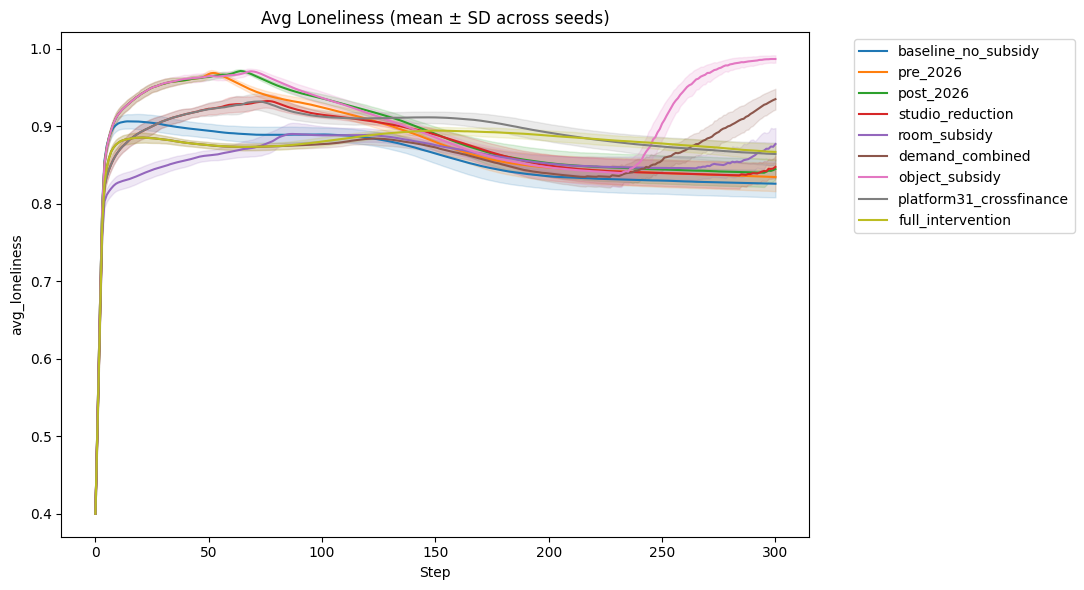

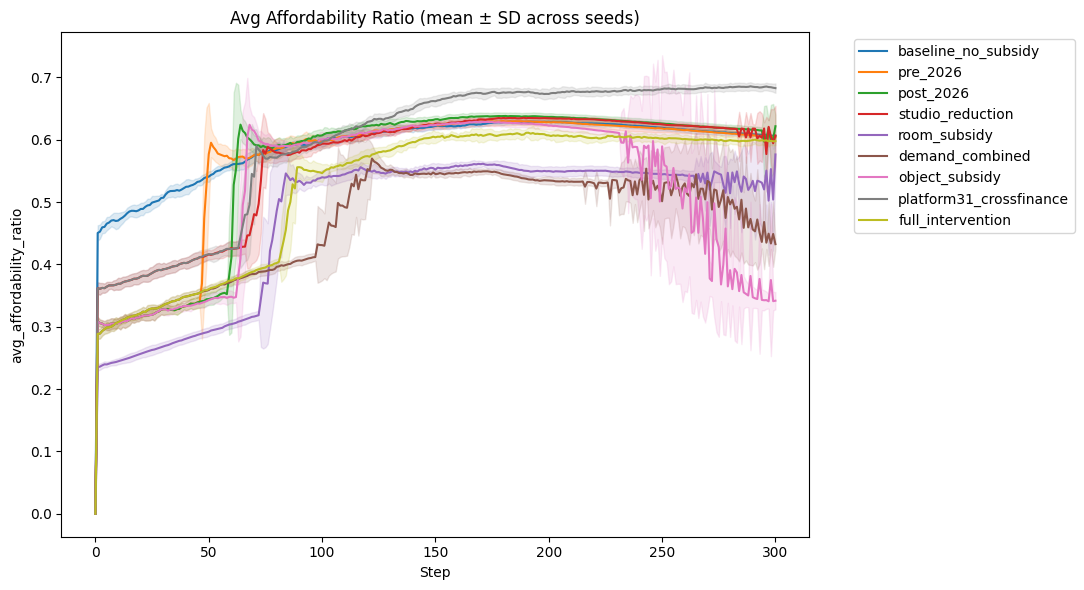

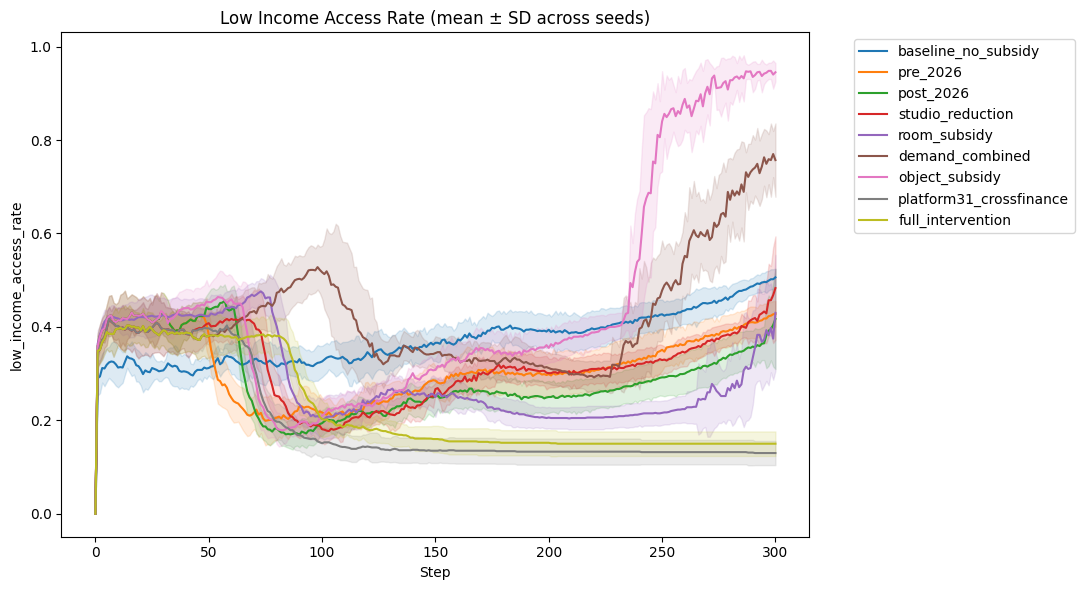

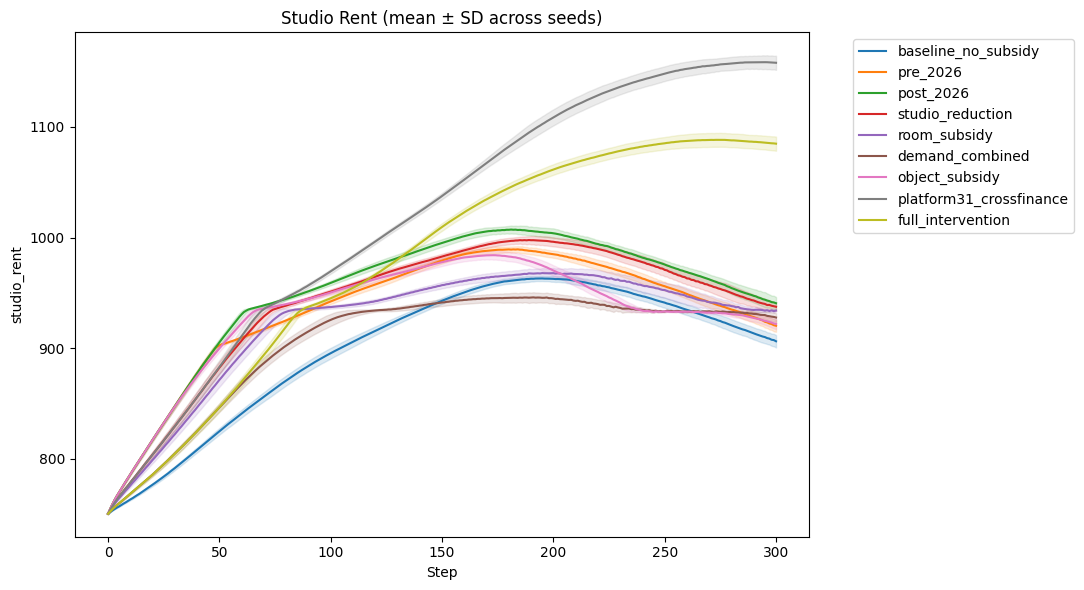

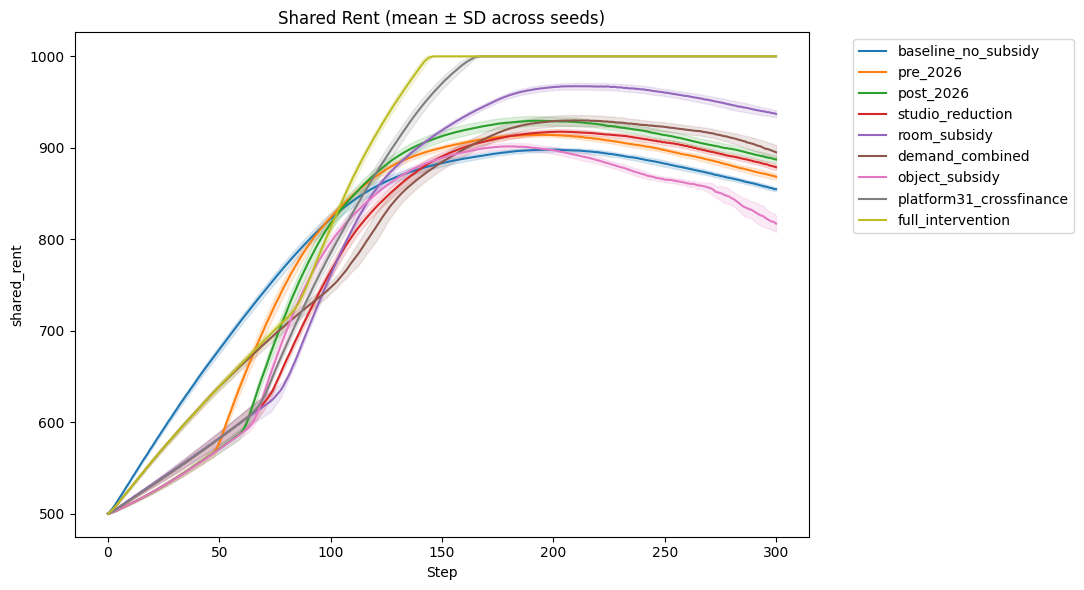

/var/folders/kw/6wrb96zd6_g9r3qs9y6kzyfc0000gn/T/ipykernel_71813/790368624.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, vert=False, showmeans=True)


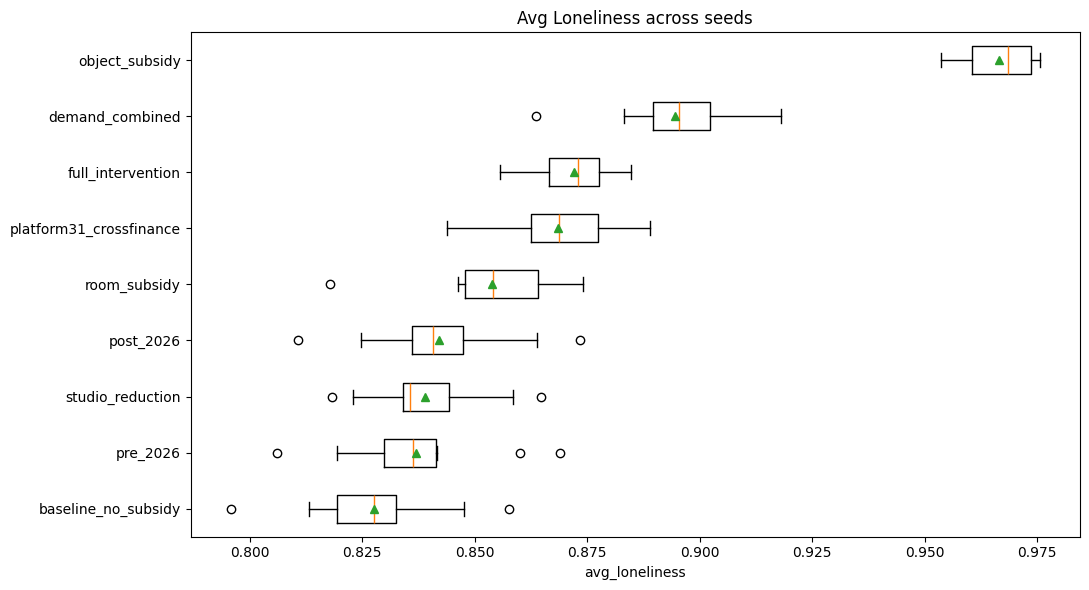


=== MARGINAL CONTRIBUTIONS (full minus each lever) ===
                            avg_loneliness  avg_affordability_ratio  \
removed_lever                                                         
crossfinance_enabled               -0.0666                   0.1666   
object_subsidy_per_room             0.0182                   0.0581   
shared_rent_allowance               0.0036                  -0.0837   
studio_allowance_reduction          0.0043                   0.0023   

                            low_income_access_rate  number_people_housed  \
removed_lever                                                              
crossfinance_enabled                       -0.6248              -101.920   
object_subsidy_per_room                    -0.0737               -46.804   
shared_rent_allowance                       0.0185               -18.238   
studio_allowance_reduction                 -0.0100                -9.966   

                            total_public_cost  
removed_leve

In [80]:
# (b) Trajectory bands (mean ± SD across seeds)
for outcome in ["avg_loneliness", "avg_affordability_ratio", "low_income_access_rate", "studio_rent", "shared_rent"]:
    plot_trajectory_band(trajectories, outcome=outcome)

# Spread of the headline outcome across seeds
plot_outcome_distributions(tidy, outcome="avg_loneliness")

# (c) Ablation: marginal contribution of each lever in full_intervention
ablation_scenarios = make_ablation_scenarios("full_intervention")
ablation_traj, ablation_tidy = run_scenarios_multiseed(
    ablation_scenarios,
    steps=DEMO_STEPS,
    seeds=DEMO_SEEDS,
    base_kwargs=DEMO_BASE,
)
print("\n=== MARGINAL CONTRIBUTIONS (full minus each lever) ===")
print(marginal_contributions(ablation_tidy).round(4))